In [28]:
from pathlib import Path
import zipfile
import re
import math

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.feature import hog

In [ ]:
# Current project folder
PROJECT_DIR = Path.cwd()

# Existing dataset folder
DATASET_DIR = PROJECT_DIR / "Prepared datasets"

# Folder for processed 28×28 images
PROCESSED_DIR = PROJECT_DIR / "processed_28x28"

# Folder for generated CSV files
CSV_DIR = PROJECT_DIR / "csv_output"

# Create output folders
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
CSV_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:")
print(PROJECT_DIR)

print("\nDataset directory:")
print(DATASET_DIR)

print("\nProcessed image directory:")
print(PROCESSED_DIR)

print("\nCSV output directory:")
print(CSV_DIR)


if not DATASET_DIR.exists():
    raise FileNotFoundError(
        f"Dataset folder was not found:\n{DATASET_DIR}"
    )

if not DATASET_DIR.is_dir():
    raise NotADirectoryError(
        f"The provided path is not a folder:\n{DATASET_DIR}"
    )

print("Dataset folder found successfully.")

Project directory:
c:\Users\Asus\OneDrive\Desktop\IPPR PRoject\Final

Dataset directory:
c:\Users\Asus\OneDrive\Desktop\IPPR PRoject\Final\Prepared datasets

Processed image directory:
c:\Users\Asus\OneDrive\Desktop\IPPR PRoject\Final\Preprocessed images

CSV output directory:
c:\Users\Asus\OneDrive\Desktop\IPPR PRoject\Final\csv_output
Dataset folder found successfully.


In [30]:
IMAGE_EXTENSIONS = {
    ".png",
    ".jpg",
    ".jpeg",
    ".bmp",
    ".tif",
    ".tiff"
}

image_paths = [
    path
    for path in DATASET_DIR.rglob("*")
    if path.is_file()
    and path.suffix.lower() in IMAGE_EXTENSIONS
]

print("Total images found:", len(image_paths))

Total images found: 540


In [31]:
#check the image extension

extension_counts = {}

for image_path in image_paths:
    extension = image_path.suffix.lower()

    extension_counts[extension] = (
        extension_counts.get(extension, 0) + 1
    )

print("Image types found:")

for extension, count in extension_counts.items():
    print(extension, ":", count)

Image types found:
.png : 540


In [32]:
# sort the images numerically

def get_numeric_filename_value(path):
    """
    Gets the last number from an image filename.

    Examples:
    img_00001.png -> 1
    img_00125.png -> 125
    """

    numbers = re.findall(r"\d+", path.stem)

    if numbers:
        return int(numbers[-1])

    return path.stem


image_paths = sorted(
    image_paths,
    key=get_numeric_filename_value
)

print("First 20 images:")

for image_path in image_paths[:20]:
    print(image_path.name)

print("Last 20 images:")

for image_path in image_paths[-20:]:
    print(image_path.name)

First 20 images:
img_00000.png
img_00001.png
img_00002.png
img_00003.png
img_00004.png
img_00005.png
img_00006.png
img_00007.png
img_00008.png
img_00009.png
img_00010.png
img_00011.png
img_00012.png
img_00013.png
img_00014.png
img_00015.png
img_00016.png
img_00017.png
img_00018.png
img_00019.png
Last 20 images:
img_00537.png
img_00538.png
img_00539.png
img_00540.png
img_00541.png
img_00542.png
img_00543.png
img_00544.png
img_00545.png
img_00546.png
img_00548.png
img_00549.png
img_00550.png
img_00551.png
img_00552.png
img_00553.png
img_00554.png
img_00555.png
img_00556.png
img_00557.png


In [33]:
#Assign digit labels

NEPALI_DIGITS = {
    0: "०",
    1: "१",
    2: "२",
    3: "३",
    4: "४",
    5: "५",
    6: "६",
    7: "७",
    8: "८",
    9: "९"
}

In [34]:
#create image metadata

metadata_rows = []

for index, image_path in enumerate(image_paths):

    # Labels repeat from 0 to 9
    label = index % 10

    # Every group contains ten digit images
    sample_group = index // 10

    metadata_rows.append({
        "image_index": index,
        "sample_group": sample_group,
        "filename": image_path.name,
        "image_path": str(image_path),
        "label": label,
        "nepali_label": NEPALI_DIGITS[label]
    })

metadata_df = pd.DataFrame(metadata_rows)

metadata_df.head(20)

,image_index,sample_group,filename,image_path,label,nepali_label
0,0,0,img_00000.png,c:\Users\Asus\OneDrive\Desktop\IPPR PRoject\Fi...,0,०
1,1,0,img_00001.png,c:\Users\Asus\OneDrive\Desktop\IPPR PRoject\Fi...,1,१
2,2,0,img_00002.png,c:\Users\Asus\OneDrive\Desktop\IPPR PRoject\Fi...,2,२
3,3,0,img_00003.png,c:\Users\Asus\OneDrive\Desktop\IPPR PRoject\Fi...,3,३
4,4,0,img_00004.png,c:\Users\Asus\OneDrive\Desktop\IPPR PRoject\Fi...,4,४
5,5,0,img_00005.png,c:\Users\Asus\OneDrive\Desktop\IPPR PRoject\Fi...,5,५
6,6,0,img_00006.png,c:\Users\Asus\OneDrive\Desktop\IPPR PRoject\Fi...,6,६
7,7,0,img_00007.png,c:\Users\Asus\OneDrive\Desktop\IPPR PRoject\Fi...,7,७
8,8,0,img_00008.png,c:\Users\Asus\OneDrive\Desktop\IPPR PRoject\Fi...,8,८
9,9,0,img_00009.png,c:\Users\Asus\OneDrive\Desktop\IPPR PRoject\Fi...,9,९


In [35]:
# Check the class distribution

class_distribution = (
    metadata_df
    .groupby(["label", "nepali_label"])
    .size()
    .reset_index(name="image_count")
)

class_distribution

print("Total images:", len(metadata_df))
print("Total digit classes:", metadata_df["label"].nunique())
print("Total sample groups:", metadata_df["sample_group"].nunique())

Total images: 540
Total digit classes: 10
Total sample groups: 54


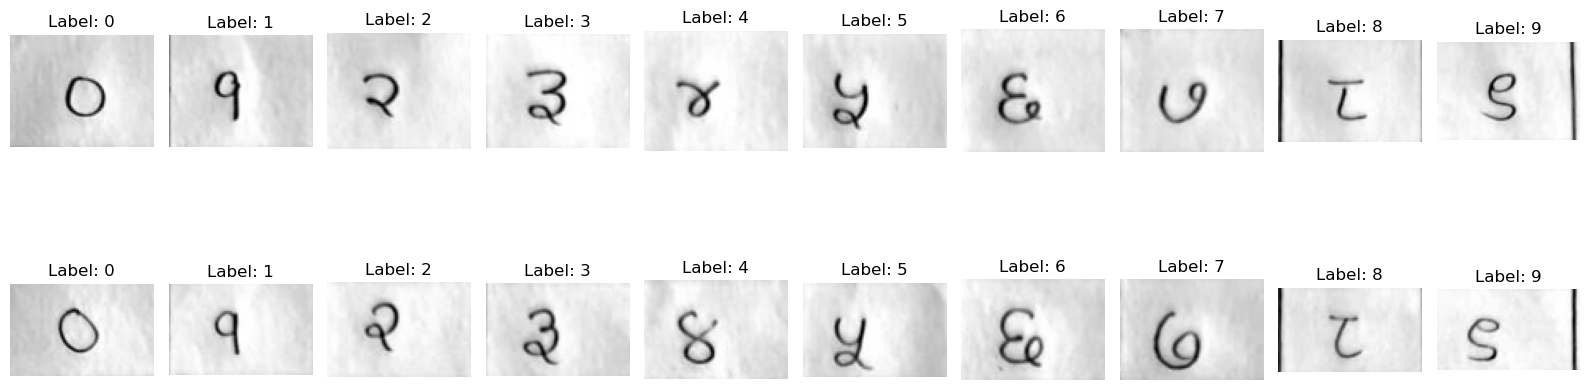

In [36]:
# display first 20 images

plt.figure(figsize=(16, 6))

number_of_images_to_show = min(
    20,
    len(metadata_df)
)

for index in range(number_of_images_to_show):

    image_path = metadata_df.loc[
        index,
        "image_path"
    ]

    label = metadata_df.loc[
        index,
        "label"
    ]

    image = cv2.imread(
        image_path,
        cv2.IMREAD_GRAYSCALE
    )

    if image is None:
        print("Could not read:", image_path)
        continue

    plt.subplot(2, 10, index + 1)
    plt.imshow(image, cmap="gray")
    plt.title(f"Label: {label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [37]:
import cv2

def read_grayscale_image(image_path):
    """
    Reads an image from the given path in grayscale format.
    """

    image = cv2.imread(
        str(image_path),
        cv2.IMREAD_GRAYSCALE
    )

    if image is None:
        raise ValueError(
            f"Could not read image from:\n{image_path}"
        )

    return image

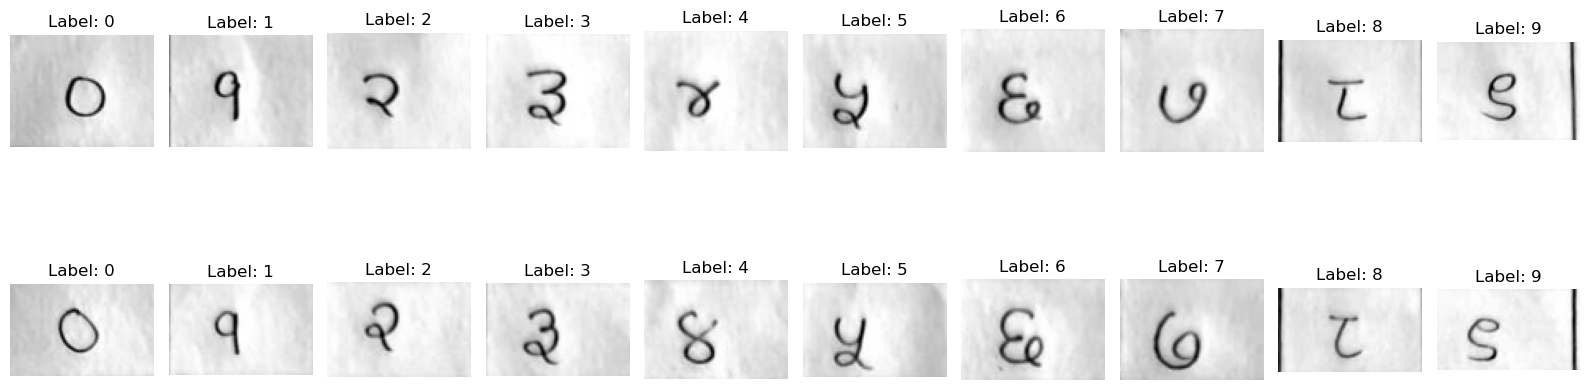

Image shape: (72, 92)


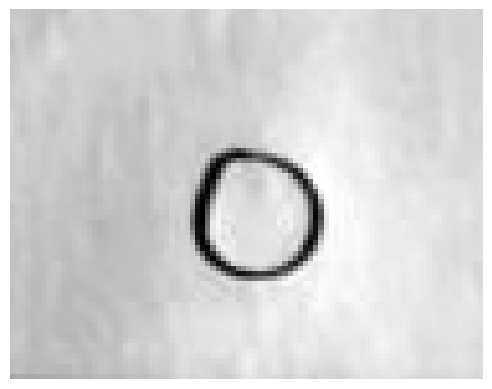

In [38]:
# Create image reading functions

plt.figure(figsize=(16, 6))

number_of_images_to_show = min(
    20,
    len(metadata_df)
)

for index in range(number_of_images_to_show):

    image_path = metadata_df.loc[
        index,
        "image_path"
    ]

    label = metadata_df.loc[
        index,
        "label"
    ]

    image = cv2.imread(
        image_path,
        cv2.IMREAD_GRAYSCALE
    )

    if image is None:
        print("Could not read:", image_path)
        continue

    plt.subplot(2, 10, index + 1)
    plt.imshow(image, cmap="gray")
    plt.title(f"Label: {label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

sample_path = metadata_df.loc[0, "image_path"]

sample_image = read_grayscale_image(sample_path)

print("Image shape:", sample_image.shape)

plt.imshow(sample_image, cmap="gray")
plt.axis("off")
plt.show()

In [39]:
# Remove long horizontal and veritcal lines

def remove_grid_lines(binary_image):
    """
    Detects and removes long horizontal and vertical grid lines.
    """

    height, width = binary_image.shape

    # Horizontal line detection kernel
    horizontal_kernel_width = max(10, width // 2)

    horizontal_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (horizontal_kernel_width, 1)
    )

    # Vertical line detection kernel
    vertical_kernel_height = max(10, height // 2)

    vertical_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (1, vertical_kernel_height)
    )

    horizontal_lines = cv2.morphologyEx(
        binary_image,
        cv2.MORPH_OPEN,
        horizontal_kernel
    )

    vertical_lines = cv2.morphologyEx(
        binary_image,
        cv2.MORPH_OPEN,
        vertical_kernel
    )

    all_lines = cv2.bitwise_or(
        horizontal_lines,
        vertical_lines
    )

    image_without_lines = cv2.subtract(
        binary_image,
        all_lines
    )

    return image_without_lines

In [40]:
# remove small noise components

def remove_small_components(binary_image):
    """
    Removes very small connected components while preserving
    the major digit strokes.
    """

    number_of_labels, labels, stats, centroids = (
        cv2.connectedComponentsWithStats(
            binary_image,
            connectivity=8
        )
    )

    if number_of_labels <= 1:
        return binary_image

    component_areas = stats[1:, cv2.CC_STAT_AREA]

    if len(component_areas) == 0:
        return binary_image

    largest_area = component_areas.max()

    # Preserve components having at least 3% of the largest component
    minimum_area = max(3, int(largest_area * 0.03))

    cleaned_image = np.zeros_like(binary_image)

    for component_index in range(1, number_of_labels):

        area = stats[
            component_index,
            cv2.CC_STAT_AREA
        ]

        if area >= minimum_area:
            cleaned_image[
                labels == component_index
            ] = 255

    return cleaned_image

In [41]:
''': Create digit normalization function

This function performs:

Grayscale conversion
Gaussian smoothing
Otsu thresholding
Grid-line removal
Noise removal
Cropping
Aspect-ratio-preserving resize
Placement on a 28
'''

def preprocess_digit(
    image_path,
    output_size=28,
    digit_area_size=20,
    remove_lines=True
):
    """
    Complete preprocessing function for handwritten Nepali digits.

    Returns:
        normalized_image: 28×28 binary image
        processing_steps: dictionary of intermediate images
    """

    # -----------------------------------
    # 1. Read grayscale image
    # -----------------------------------
    grayscale = read_grayscale_image(image_path)

    # -----------------------------------
    # 2. Gaussian blur
    # -----------------------------------
    blurred = cv2.GaussianBlur(
        grayscale,
        (3, 3),
        0
    )

    # -----------------------------------
    # 3. Otsu thresholding
    # -----------------------------------
    _, binary = cv2.threshold(
        blurred,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    # Ensure that the digit is white and background is black
    foreground_ratio = np.count_nonzero(binary) / binary.size

    if foreground_ratio > 0.50:
        binary = cv2.bitwise_not(binary)

    # -----------------------------------
    # 4. Remove grid lines
    # -----------------------------------
    if remove_lines:
        no_lines = remove_grid_lines(binary)
    else:
        no_lines = binary.copy()

    # -----------------------------------
    # 5. Morphological closing
    # -----------------------------------
    closing_kernel = np.ones(
        (2, 2),
        dtype=np.uint8
    )

    closed_image = cv2.morphologyEx(
        no_lines,
        cv2.MORPH_CLOSE,
        closing_kernel
    )

    # -----------------------------------
    # 6. Remove small components
    # -----------------------------------
    cleaned = remove_small_components(
        closed_image
    )

    # -----------------------------------
    # 7. Find foreground coordinates
    # -----------------------------------
    foreground_points = cv2.findNonZero(
        cleaned
    )

    # Return an empty image when no digit is found
    if foreground_points is None:

        normalized_image = np.zeros(
            (output_size, output_size),
            dtype=np.uint8
        )

        return normalized_image, {
            "grayscale": grayscale,
            "blurred": blurred,
            "binary": binary,
            "no_lines": no_lines,
            "cleaned": cleaned
        }

    # -----------------------------------
    # 8. Crop the digit
    # -----------------------------------
    x, y, width, height = cv2.boundingRect(
        foreground_points
    )

    cropped = cleaned[
        y:y + height,
        x:x + width
    ]

    # -----------------------------------
    # 9. Preserve aspect ratio
    # -----------------------------------
    if width > height:

        new_width = digit_area_size

        new_height = max(
            1,
            int(height * digit_area_size / width)
        )

    else:

        new_height = digit_area_size

        new_width = max(
            1,
            int(width * digit_area_size / height)
        )

    resized = cv2.resize(
        cropped,
        (new_width, new_height),
        interpolation=cv2.INTER_AREA
    )

    # Convert back into binary form
    _, resized = cv2.threshold(
        resized,
        127,
        255,
        cv2.THRESH_BINARY
    )

    # -----------------------------------
    # 10. Create 28×28 canvas
    # -----------------------------------
    normalized_image = np.zeros(
        (output_size, output_size),
        dtype=np.uint8
    )

    x_offset = (output_size - new_width) // 2
    y_offset = (output_size - new_height) // 2

    normalized_image[
        y_offset:y_offset + new_height,
        x_offset:x_offset + new_width
    ] = resized

    processing_steps = {
        "grayscale": grayscale,
        "blurred": blurred,
        "binary": binary,
        "no_lines": no_lines,
        "cleaned": cleaned,
        "cropped": cropped,
        "normalized": normalized_image
    }

    return normalized_image, processing_steps

Normalized image shape: (28, 28)


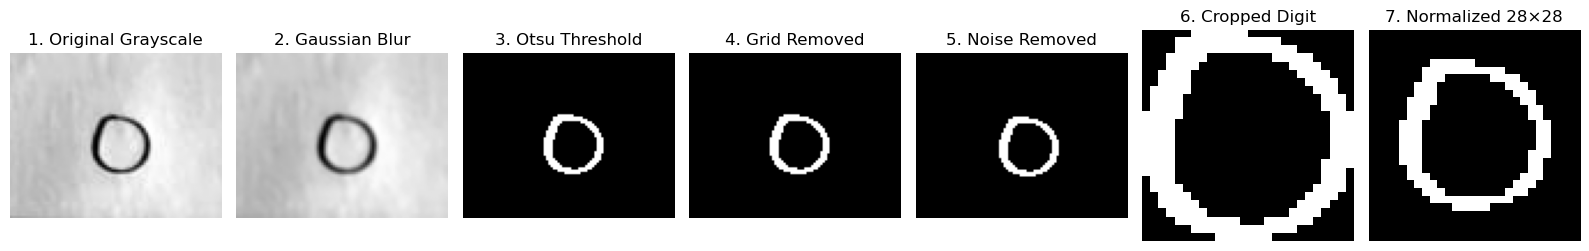

In [42]:
# test preprocessing in one image

sample_path = metadata_df.loc[0, "image_path"]

normalized_sample, steps = preprocess_digit(
    sample_path
)

print("Normalized image shape:", normalized_sample.shape)

step_titles = [
    ("grayscale", "1. Original Grayscale"),
    ("blurred", "2. Gaussian Blur"),
    ("binary", "3. Otsu Threshold"),
    ("no_lines", "4. Grid Removed"),
    ("cleaned", "5. Noise Removed"),
    ("cropped", "6. Cropped Digit"),
    ("normalized", "7. Normalized 28×28")
]

plt.figure(figsize=(16, 5))

for index, (step_name, title) in enumerate(step_titles):

    plt.subplot(1, len(step_titles), index + 1)

    plt.imshow(
        steps[step_name],
        cmap="gray"
    )

    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

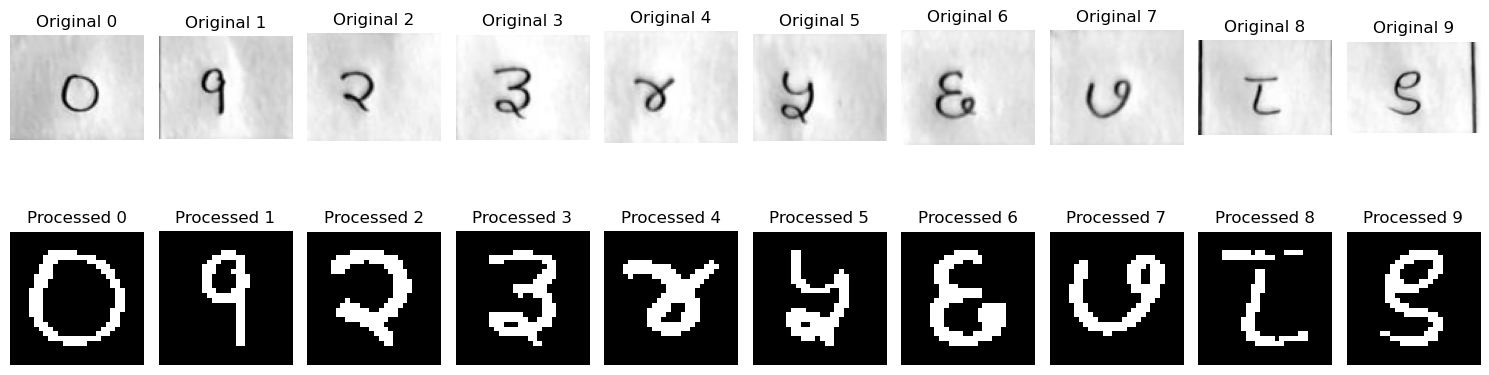

In [43]:
#check preprocessing in all 10 images
plt.figure(figsize=(15, 5))

for index in range(10):

    image_path = metadata_df.loc[
        index,
        "image_path"
    ]

    label = metadata_df.loc[
        index,
        "label"
    ]

    processed_image, _ = preprocess_digit(
        image_path
    )

    plt.subplot(2, 10, index + 1)

    original_image = read_grayscale_image(
        image_path
    )

    plt.imshow(original_image, cmap="gray")
    plt.title(f"Original {label}")
    plt.axis("off")

    plt.subplot(2, 10, index + 11)
    plt.imshow(processed_image, cmap="gray")
    plt.title(f"Processed {label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [44]:
# save all processed images

processed_image_records = []

for index, row in metadata_df.iterrows():

    original_path = row["image_path"]
    label = row["label"]
    sample_group = row["sample_group"]

    processed_image, _ = preprocess_digit(
        original_path
    )

    output_filename = (
        f"group_{sample_group:03d}"
        f"_digit_{label}"
        f"_index_{index:04d}.png"
    )

    output_path = (
        PROCESSED_DIR /
        output_filename
    )

    saved = cv2.imwrite(
        str(output_path),
        processed_image
    )

    if not saved:
        print("Could not save:", output_path)

    processed_image_records.append({
        "image_index": index,
        "sample_group": sample_group,
        "label": label,
        "nepali_label": NEPALI_DIGITS[label],
        "original_filename": row["filename"],
        "processed_filename": output_filename,
        "processed_path": str(output_path)
    })

    if (index + 1) % 50 == 0:
        print(
            f"Processed {index + 1} "
            f"of {len(metadata_df)} images"
        )

preprocessed_images = pd.DataFrame(
    processed_image_records
)

print("Processing completed.")
print("Total processed images:", len(preprocessed_images))

Processed 50 of 540 images
Processed 100 of 540 images
Processed 150 of 540 images
Processed 200 of 540 images
Processed 250 of 540 images
Processed 300 of 540 images
Processed 350 of 540 images
Processed 400 of 540 images
Processed 450 of 540 images
Processed 500 of 540 images
Processing completed.
Total processed images: 540
